# 07 - Probability Calibration

## Objective

This notebook calibrates the probability estimates produced by the tuned XGBoost model.

The workflow uses:

1. Model-training data to fit the tuned XGBoost model
2. A separate calibration set to learn probability calibration
3. The untouched test set only for final evaluation

Calibration methods compared:

- Uncalibrated XGBoost
- Sigmoid calibration (Platt scaling)
- Isotonic calibration

Evaluation metrics:

- Brier Score
- Log Loss
- ROC-AUC
- PR-AUC

The final calibrated probability model will be selected based on calibration quality
without using the test set for model fitting or calibration.

In [14]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
    classification_report
)

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator

import matplotlib.pyplot as plt

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [15]:
file_path = "../data/raw/default of credit card clients.xls"
df = pd.read_excel(file_path, header=1)

In [16]:
# Reload the original dataset after kernel restart

import pandas as pd

file_path = "../data/raw/default of credit card clients.xls"

df = pd.read_excel(file_path, header=1)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully.
Shape: (30000, 25)

First 5 rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



Columns:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [17]:
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Standardize column names (replace spaces with dots)
df.columns = df.columns.str.strip().str.replace(' ', '.')

TARGET = "default.payment.next.month"

# 2. Verify dataset target & missing values
print("Target exists:", TARGET in df.columns)
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate IDs:", df["ID"].duplicated().sum() if "ID" in df.columns else "No ID column")
print("Missing values:", df.isna().sum().sum())

print("\nTarget distribution:")
print(df[TARGET].value_counts())
print("\nTarget proportions:")
print(df[TARGET].value_counts(normalize=True))

# 3. Create features (X) and target (y) keeping original index intact
X = df.drop(columns=[TARGET, "ID"], errors="ignore").copy()
y = df[TARGET].copy()

# 4. Split TEST set (20% -> 6,000 samples)
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# 5. Split DEVELOPMENT set into MODEL TRAIN (80% of dev -> 19,200) and CALIBRATION (20% of dev -> 4,800)
X_model_train, X_calibration, y_model_train, y_calibration = train_test_split(
    X_dev, y_dev, test_size=0.20, stratify=y_dev, random_state=42
)

# 6. Critical Leakage Check
train_idx = set(X_model_train.index)
cal_idx = set(X_calibration.index)
test_idx = set(X_test.index)

print("\n--- Leakage Verification ---")
print("Model train ∩ calibration:", len(train_idx.intersection(cal_idx)))
print("Model train ∩ test:", len(train_idx.intersection(test_idx)))
print("Calibration ∩ test:", len(cal_idx.intersection(test_idx)))
print("Total unique observations:", len(train_idx | cal_idx | test_idx))

Target exists: True
Duplicate rows: 0
Duplicate IDs: 0
Missing values: 0

Target distribution:
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

Target proportions:
default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

--- Leakage Verification ---
Model train ∩ calibration: 0
Model train ∩ test: 0
Calibration ∩ test: 0
Total unique observations: 30000


In [19]:
print("Dataset shape:", df.shape)
print("Dataset index unique:", df.index.is_unique)

print("\nTarget distribution:")
print(df["default.payment.next.month"].value_counts())

print("\nTarget proportions:")
print(df["default.payment.next.month"].value_counts(normalize=True))

Dataset shape: (30000, 25)
Dataset index unique: True

Target distribution:
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

Target proportions:
default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


#### create X and y ONCE

In [21]:
TARGET = "default.payment.next.month"

# Remove ID because it is only an identifier
X = df.drop(columns=[TARGET, "ID"], errors="ignore").copy()
y = df[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX index range:")
print(X.index.min(), X.index.max())

print("\ny index range:")
print(y.index.min(), y.index.max())

X shape: (30000, 23)
y shape: (30000,)

X index range:
0 29999

y index range:
0 29999


#### Create the TEST set ONCE

In [22]:
X_development, X_test, y_development, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Development set:", X_development.shape)
print("Test set:", X_test.shape)

print("\nDevelopment default rate:", y_development.mean())
print("Test default rate:", y_test.mean())

Development set: (24000, 23)
Test set: (6000, 23)

Development default rate: 0.22120833333333334
Test default rate: 0.22116666666666668


#### Split development data into MODEL TRAIN and CALIBRATION

In [23]:
X_model_train, X_calibration, y_model_train, y_calibration = train_test_split(
    X_development,
    y_development,
    test_size=0.20,
    stratify=y_development,
    random_state=42
)

print("Model training:", X_model_train.shape)
print("Calibration:", X_calibration.shape)
print("Test:", X_test.shape)

print("\nModel training default rate:", y_model_train.mean())
print("Calibration default rate:", y_calibration.mean())
print("Test default rate:", y_test.mean())

Model training: (19200, 23)
Calibration: (4800, 23)
Test: (6000, 23)

Model training default rate: 0.22119791666666666
Calibration default rate: 0.22125
Test default rate: 0.22116666666666668


In [24]:
model_train_indices = set(X_model_train.index)
calibration_indices = set(X_calibration.index)
test_indices = set(X_test.index)

print("Model train ∩ calibration:",
      len(model_train_indices.intersection(calibration_indices)))

print("Model train ∩ test:",
      len(model_train_indices.intersection(test_indices)))

print("Calibration ∩ test:",
      len(calibration_indices.intersection(test_indices)))

print("\nTotal unique observations:",
      len(
          model_train_indices |
          calibration_indices |
          test_indices
      ))

Model train ∩ calibration: 0
Model train ∩ test: 0
Calibration ∩ test: 0

Total unique observations: 30000


Additional safety check

In [25]:
assert len(model_train_indices.intersection(calibration_indices)) == 0
assert len(model_train_indices.intersection(test_indices)) == 0
assert len(calibration_indices.intersection(test_indices)) == 0

assert (
    len(model_train_indices)
    + len(calibration_indices)
    + len(test_indices)
    == len(df)
)

print("✓ DATA SPLIT PASSED ALL LEAKAGE CHECKS")

✓ DATA SPLIT PASSED ALL LEAKAGE CHECKS


#### Check target distributions

In [26]:
split_summary = pd.DataFrame({
    "Dataset": [
        "Full Dataset",
        "Model Training",
        "Calibration",
        "Test"
    ],
    "Samples": [
        len(df),
        len(y_model_train),
        len(y_calibration),
        len(y_test)
    ],
    "Defaults": [
        y.sum(),
        y_model_train.sum(),
        y_calibration.sum(),
        y_test.sum()
    ],
    "Default Rate": [
        y.mean(),
        y_model_train.mean(),
        y_calibration.mean(),
        y_test.mean()
    ]
})

split_summary

,Dataset,Samples,Defaults,Default Rate
0,Full Dataset,30000,6636,0.221200
1,Model Training,19200,4247,0.221198
2,Calibration,4800,1062,0.221250
3,Test,6000,1327,0.221167


#### Train the XGBoost model ONLY on model training data

In [27]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.02,
    max_depth=6,
    min_child_weight=1,
    subsample=0.7,
    colsample_bytree=0.9,
    gamma=0.3,
    reg_alpha=0.01,
    reg_lambda=2,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

#### Define the feature types

In [28]:
# Display all feature names
print("Features:")
for i, col in enumerate(X.columns, 1):
    print(f"{i:2d}. {col}")

print("\nTotal features:", len(X.columns))

Features:
 1. LIMIT_BAL
 2. SEX
 3. EDUCATION
 4. MARRIAGE
 5. AGE
 6. PAY_0
 7. PAY_2
 8. PAY_3
 9. PAY_4
10. PAY_5
11. PAY_6
12. BILL_AMT1
13. BILL_AMT2
14. BILL_AMT3
15. BILL_AMT4
16. BILL_AMT5
17. BILL_AMT6
18. PAY_AMT1
19. PAY_AMT2
20. PAY_AMT3
21. PAY_AMT4
22. PAY_AMT5
23. PAY_AMT6

Total features: 23


In [29]:
# Identify numeric and categorical columns

categorical_features = [
    col for col in ["SEX", "EDUCATION", "MARRIAGE"]
    if col in X.columns
]

numeric_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Number of numeric features:", len(numeric_features))

Categorical features:
['SEX', 'EDUCATION', 'MARRIAGE']

Numeric features:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Number of categorical features: 3
Number of numeric features: 20


#### Build the preprocessing pipeline

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [31]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

#### Create the XGBoost model

In [32]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.02,
    max_depth=6,
    min_child_weight=1,
    subsample=0.7,
    colsample_bytree=0.9,
    gamma=0.3,
    reg_alpha=0.01,
    reg_lambda=2,
    
    objective="binary:logistic",
    eval_metric="logloss",
    
    random_state=42,
    n_jobs=-1
)

In [33]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb_model)
    ]
)

#### Train ONLY on the 19,200 model-training observations

In [34]:
print("Training XGBoost...")

xgb_pipeline.fit(
    X_model_train,
    y_model_train
)

print("✓ XGBoost training completed.")

Training XGBoost...
✓ XGBoost training completed.


#### Generate predictions for each split

In [35]:
# Model-training probabilities
train_prob = xgb_pipeline.predict_proba(
    X_model_train
)[:, 1]

# Calibration probabilities
calibration_prob = xgb_pipeline.predict_proba(
    X_calibration
)[:, 1]

# Test probabilities
test_prob = xgb_pipeline.predict_proba(
    X_test
)[:, 1]

print("Training probabilities:", len(train_prob))
print("Calibration probabilities:", len(calibration_prob))
print("Test probabilities:", len(test_prob))

Training probabilities: 19200
Calibration probabilities: 4800
Test probabilities: 6000


#### Check probability ranges

In [36]:
probability_summary = pd.DataFrame({
    "Dataset": [
        "Model Training",
        "Calibration",
        "Test"
    ],
    "Mean Probability": [
        train_prob.mean(),
        calibration_prob.mean(),
        test_prob.mean()
    ],
    "Median Probability": [
        np.median(train_prob),
        np.median(calibration_prob),
        np.median(test_prob)
    ],
    "Minimum Probability": [
        train_prob.min(),
        calibration_prob.min(),
        test_prob.min()
    ],
    "Maximum Probability": [
        train_prob.max(),
        calibration_prob.max(),
        test_prob.max()
    ]
})

probability_summary

,Dataset,Mean Probability,Median Probability,Minimum Probability,Maximum Probability
0,Model Training,0.220661,0.144509,0.028203,0.894300
1,Calibration,0.218194,0.144148,0.027592,0.883586
2,Test,0.220279,0.145156,0.027739,0.891787


#### Evaluate the UNCALIBRATED model on the test set

In [37]:
uncalibrated_test_pred = (
    test_prob >= 0.50
).astype(int)

print("Uncalibrated XGBoost")
print("=" * 50)

print(
    "Accuracy:",
    accuracy_score(y_test, uncalibrated_test_pred)
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_test,
        uncalibrated_test_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        uncalibrated_test_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        uncalibrated_test_pred,
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        uncalibrated_test_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        test_prob
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        test_prob
    )
)

print(
    "Brier Score:",
    brier_score_loss(
        y_test,
        test_prob
    )
)

print(
    "Log Loss:",
    log_loss(
        y_test,
        test_prob
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        uncalibrated_test_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        uncalibrated_test_pred,
        target_names=["Non-Default", "Default"],
        zero_division=0
    )
)

Uncalibrated XGBoost
Accuracy: 0.8186666666666667
Balanced Accuracy: 0.6531841031976573
Precision: 0.669024045261669
Recall: 0.35644310474755087
F1: 0.46509341199606685
ROC-AUC: 0.7790855805392327
PR-AUC: 0.5584518650048426
Brier Score: 0.13518281280994415
Log Loss: 0.4300888776779175

Confusion Matrix:
[[4439  234]
 [ 854  473]]

Classification Report:
              precision    recall  f1-score   support

 Non-Default       0.84      0.95      0.89      4673
     Default       0.67      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



#### Perform the first sanity check

In [38]:
print("ROC-AUC sanity check")
print("=" * 50)

print("Model training ROC-AUC:",
      roc_auc_score(y_model_train, train_prob))

print("Calibration ROC-AUC:",
      roc_auc_score(y_calibration, calibration_prob))

print("Test ROC-AUC:",
      roc_auc_score(y_test, test_prob))

ROC-AUC sanity check
Model training ROC-AUC: 0.8424750742814889
Calibration ROC-AUC: 0.7801334641222282
Test ROC-AUC: 0.7790855805392327


#### Verify that calibration probabilities actually belong to calibration rows

In [39]:
print("Shape verification")
print("=" * 50)

print("X_model_train:", X_model_train.shape)
print("train_prob:", train_prob.shape)

print("X_calibration:", X_calibration.shape)
print("calibration_prob:", calibration_prob.shape)

print("X_test:", X_test.shape)
print("test_prob:", test_prob.shape)

assert len(train_prob) == len(y_model_train)
assert len(calibration_prob) == len(y_calibration)
assert len(test_prob) == len(y_test)

print("\n✓ Probability-to-target alignment passed")


Shape verification
X_model_train: (19200, 23)
train_prob: (19200,)
X_calibration: (4800, 23)
calibration_prob: (4800,)
X_test: (6000, 23)
test_prob: (6000,)

✓ Probability-to-target alignment passed


#### Fit calibration

In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# CALIBRATION (Using FrozenEstimator)

# 1. Sigmoid Calibrator
sigmoid_calibrator = CalibratedClassifierCV(
    estimator=FrozenEstimator(xgb_pipeline),
    method="sigmoid"
)
sigmoid_calibrator.fit(X_calibration, y_calibration)

# 2. Isotonic Calibrator
isotonic_calibrator = CalibratedClassifierCV(
    estimator=FrozenEstimator(xgb_pipeline),
    method="isotonic"
)
isotonic_calibrator.fit(X_calibration, y_calibration)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","FrozenEstimat...None, ...))]))"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,[<sklearn.cali...001E29B0C2C90>

#### Generate probabilities

In [ ]:
# CALIBRATION SET PROBABILITIES

calibration_prob_uncalibrated = xgb_pipeline.predict_proba(
    X_calibration
)[:, 1]

calibration_prob_sigmoid = sigmoid_calibrator.predict_proba(
    X_calibration
)[:, 1]

calibration_prob_isotonic = isotonic_calibrator.predict_proba(
    X_calibration
)[:, 1]


# TEST SET PROBABILITIES

test_prob_uncalibrated = xgb_pipeline.predict_proba(
    X_test
)[:, 1]

test_prob_sigmoid = sigmoid_calibrator.predict_proba(
    X_test
)[:, 1]

test_prob_isotonic = isotonic_calibrator.predict_proba(
    X_test
)[:, 1]


print("Calibration probabilities:")
print("Uncalibrated:", len(calibration_prob_uncalibrated))
print("Sigmoid:", len(calibration_prob_sigmoid))
print("Isotonic:", len(calibration_prob_isotonic))

print("\nTest probabilities:")
print("Uncalibrated:", len(test_prob_uncalibrated))
print("Sigmoid:", len(test_prob_sigmoid))
print("Isotonic:", len(test_prob_isotonic))

Calibration probabilities:
Uncalibrated: 4800
Sigmoid: 4800
Isotonic: 4800

Test probabilities:
Uncalibrated: 6000
Sigmoid: 6000
Isotonic: 6000


#### Verify probability alignment

In [46]:
# ALIGNMENT CHECK

assert len(X_calibration) == len(y_calibration)
assert len(X_calibration) == len(calibration_prob_uncalibrated)
assert len(X_calibration) == len(calibration_prob_sigmoid)
assert len(X_calibration) == len(calibration_prob_isotonic)

assert len(X_test) == len(y_test)
assert len(X_test) == len(test_prob_uncalibrated)
assert len(X_test) == len(test_prob_sigmoid)
assert len(X_test) == len(test_prob_isotonic)

print("✓ Calibration probability alignment passed.")
print("✓ Test probability alignment passed.")

✓ Calibration probability alignment passed.
✓ Test probability alignment passed.


#### Check the probability distributions

In [47]:
probability_summary = pd.DataFrame({
    "Model": [
        "Uncalibrated",
        "Sigmoid",
        "Isotonic"
    ],
    "Mean Probability": [
        test_prob_uncalibrated.mean(),
        test_prob_sigmoid.mean(),
        test_prob_isotonic.mean()
    ],
    "Median Probability": [
        np.median(test_prob_uncalibrated),
        np.median(test_prob_sigmoid),
        np.median(test_prob_isotonic)
    ],
    "Minimum Probability": [
        test_prob_uncalibrated.min(),
        test_prob_sigmoid.min(),
        test_prob_isotonic.min()
    ],
    "Maximum Probability": [
        test_prob_uncalibrated.max(),
        test_prob_sigmoid.max(),
        test_prob_isotonic.max()
    ]
})

display(probability_summary)

,Model,Mean Probability,Median Probability,Minimum Probability,Maximum Probability
0,Uncalibrated,0.220279,0.145156,0.027739,0.891787
1,Sigmoid,0.223229,0.138181,0.080391,0.883556
2,Isotonic,0.223287,0.183962,0.000000,1.000000


#### Evaluate calibration properly

In [49]:
# CALIBRATION EVALUATION FUNCTION

def evaluate_probability_model(
    model_name,
    y_true,
    probabilities,
    threshold=0.5
):
    
    predictions = (probabilities >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions
    ).ravel()
    
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_true, predictions),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        ),
        "PR-AUC": average_precision_score(
            y_true,
            probabilities
        ),
        "Brier Score": brier_score_loss(
            y_true,
            probabilities
        ),
        "Log Loss": log_loss(
            y_true,
            probabilities
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [50]:
calibration_results = pd.DataFrame([
    
    evaluate_probability_model(
        "Uncalibrated XGBoost",
        y_test,
        test_prob_uncalibrated
    ),
    
    evaluate_probability_model(
        "Sigmoid Calibrated XGBoost",
        y_test,
        test_prob_sigmoid
    ),
    
    evaluate_probability_model(
        "Isotonic Calibrated XGBoost",
        y_test,
        test_prob_isotonic
    )
])

display(
    calibration_results[
        [
            "Model",
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "PR-AUC",
            "Brier Score",
            "Log Loss"
        ]
    ]
)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier Score,Log Loss
0,Uncalibrated XGBoost,0.818667,0.653184,0.669024,0.356443,0.465093,0.779086,0.558452,0.135183,0.430089
1,Sigmoid Calibrated XGBoost,0.818500,0.653077,0.668079,0.356443,0.464865,0.779086,0.558452,0.136268,0.434392
2,Isotonic Calibrated XGBoost,0.816833,0.642295,0.676471,0.329314,0.442980,0.775755,0.544534,0.135642,0.437038


#### Calibration curves

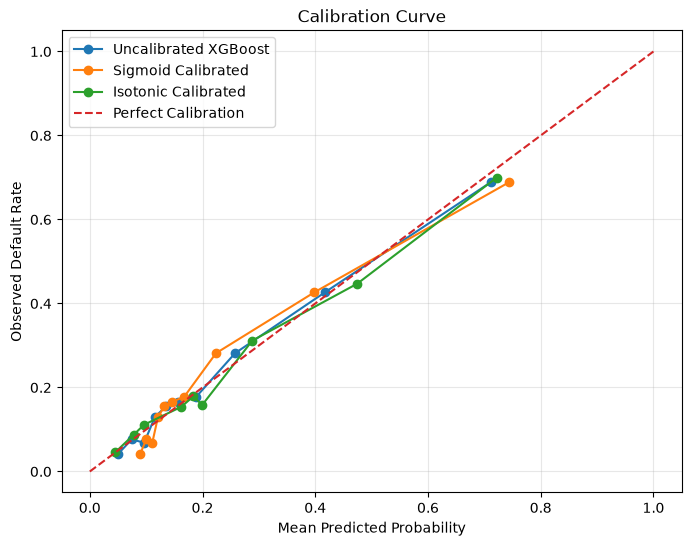

In [51]:
# CALIBRATION CURVES

fraction_uncal, mean_uncal = calibration_curve(
    y_test,
    test_prob_uncalibrated,
    n_bins=10,
    strategy="quantile"
)

fraction_sigmoid, mean_sigmoid = calibration_curve(
    y_test,
    test_prob_sigmoid,
    n_bins=10,
    strategy="quantile"
)

fraction_isotonic, mean_isotonic = calibration_curve(
    y_test,
    test_prob_isotonic,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(8, 6))

plt.plot(
    mean_uncal,
    fraction_uncal,
    marker="o",
    label="Uncalibrated XGBoost"
)

plt.plot(
    mean_sigmoid,
    fraction_sigmoid,
    marker="o",
    label="Sigmoid Calibrated"
)

plt.plot(
    mean_isotonic,
    fraction_isotonic,
    marker="o",
    label="Isotonic Calibrated"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Probability distributions

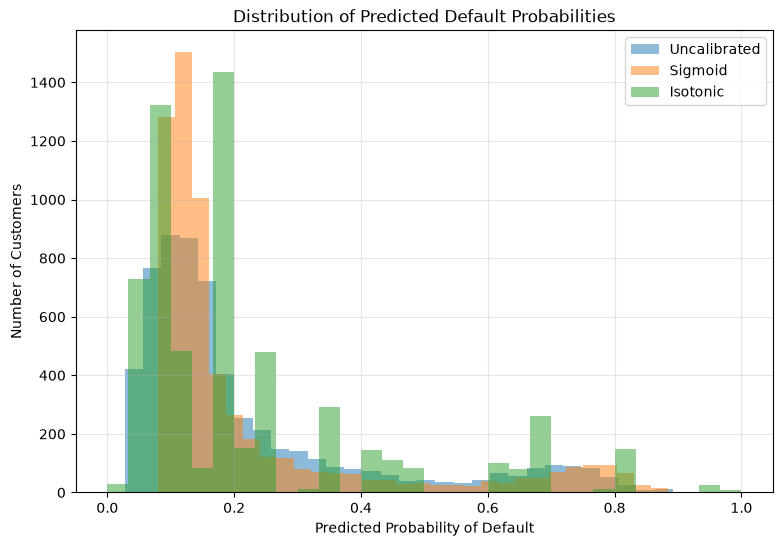

In [52]:
plt.figure(figsize=(9, 6))

plt.hist(
    test_prob_uncalibrated,
    bins=30,
    alpha=0.5,
    label="Uncalibrated"
)

plt.hist(
    test_prob_sigmoid,
    bins=30,
    alpha=0.5,
    label="Sigmoid"
)

plt.hist(
    test_prob_isotonic,
    bins=30,
    alpha=0.5,
    label="Isotonic"
)

plt.xlabel("Predicted Probability of Default")
plt.ylabel("Number of Customers")
plt.title("Distribution of Predicted Default Probabilities")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Reliability table

In [53]:
def reliability_table(y_true, probabilities, n_bins=10):

    df = pd.DataFrame({
        "actual": np.asarray(y_true),
        "probability": np.asarray(probabilities)
    })

    df["bin"] = pd.qcut(
        df["probability"],
        q=n_bins,
        duplicates="drop"
    )

    reliability = (
        df.groupby("bin", observed=True)
        .agg(
            Customers=("actual", "size"),
            Mean_Predicted_Probability=("probability", "mean"),
            Actual_Default_Rate=("actual", "mean")
        )
        .reset_index()
    )

    reliability["Calibration_Error"] = (
        reliability["Actual_Default_Rate"]
        - reliability["Mean_Predicted_Probability"]
    )

    return reliability

In [54]:
print("SIGMOID RELIABILITY TABLE")
display(
    reliability_table(
        y_test,
        test_prob_sigmoid
    )
)

SIGMOID RELIABILITY TABLE


,bin,Customers,Mean_Predicted_Probability,Actual_Default_Rate,Calibration_Error
0,"(0.0794, 0.0952]",600,0.089395,0.041667,-0.047728
1,"(0.0952, 0.106]",600,0.100198,0.076667,-0.023531
2,"(0.106, 0.116]",600,0.110858,0.068333,-0.042525
3,"(0.116, 0.126]",600,0.121022,0.130000,0.008978
4,"(0.126, 0.138]",600,0.132229,0.155000,0.022771
5,"(0.138, 0.154]",600,0.145072,0.165000,0.019928
6,"(0.154, 0.188]",600,0.167728,0.178333,0.010606
7,"(0.188, 0.276]",600,0.223926,0.281667,0.057741
8,"(0.276, 0.609]",600,0.398446,0.426667,0.028221
9,"(0.609, 0.884]",600,0.743420,0.688333,-0.055086


In [55]:
print("ISOTONIC RELIABILITY TABLE")
display(
    reliability_table(
        y_test,
        test_prob_isotonic
    )
)

ISOTONIC RELIABILITY TABLE


,bin,Customers,Mean_Predicted_Probability,Actual_Default_Rate,Calibration_Error
0,"(-1e-08, 0.051282056]",679,0.045109,0.045655,0.000547
1,"(0.051282056, 0.081018515]",1282,0.077730,0.087363,0.009633
2,"(0.081018515, 0.10135135]",450,0.096020,0.111111,0.015091
3,"(0.10135135, 0.18396226]",643,0.162270,0.153966,-0.008304
4,"(0.18396226, 0.18396227]",765,0.183962,0.179085,-0.004877
5,"(0.18396227, 0.23300971]",392,0.199276,0.158163,-0.041113
6,"(0.23300971, 0.35185185]",770,0.288333,0.311688,0.023355
7,"(0.35185185, 0.6081081]",463,0.474427,0.447084,-0.027343
8,"(0.6081081, 1.0]",556,0.721891,0.699640,-0.022251


#### Find the best calibration method

In [56]:
best_brier = calibration_results.loc[
    calibration_results["Brier Score"].idxmin()
]

best_logloss = calibration_results.loc[
    calibration_results["Log Loss"].idxmin()
]

print("Best by Brier Score:")
print(best_brier)

print("\nBest by Log Loss:")
print(best_logloss)

Best by Brier Score:
Model                Uncalibrated XGBoost
Accuracy                         0.818667
Balanced Accuracy                0.653184
Precision                        0.669024
Recall                           0.356443
F1                               0.465093
ROC-AUC                          0.779086
PR-AUC                           0.558452
Brier Score                      0.135183
Log Loss                         0.430089
TN                                   4439
FP                                    234
FN                                    854
TP                                    473
Name: 0, dtype: object

Best by Log Loss:
Model                Uncalibrated XGBoost
Accuracy                         0.818667
Balanced Accuracy                0.653184
Precision                        0.669024
Recall                           0.356443
F1                               0.465093
ROC-AUC                          0.779086
PR-AUC                           0.558452
Brier Score  

## IIIIIII


#### Go back to the clean model-comparison section

In [57]:
# STEP 1 — VERIFY CLEAN DATA SPLITS

print("Model training:", X_model_train.shape, y_model_train.shape)
print("Calibration:", X_calibration.shape, y_calibration.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nDefault rates:")
print("Model training:", y_model_train.mean())
print("Calibration:", y_calibration.mean())
print("Test:", y_test.mean())

print("\nLeakage checks:")
print(
    "Train ∩ Calibration:",
    len(set(X_model_train.index) & set(X_calibration.index))
)

print(
    "Train ∩ Test:",
    len(set(X_model_train.index) & set(X_test.index))
)

print(
    "Calibration ∩ Test:",
    len(set(X_calibration.index) & set(X_test.index))
)

Model training: (19200, 23) (19200,)
Calibration: (4800, 23) (4800,)
Test: (6000, 23) (6000,)

Default rates:
Model training: 0.22119791666666666
Calibration: 0.22125
Test: 0.22116666666666668

Leakage checks:
Train ∩ Calibration: 0
Train ∩ Test: 0
Calibration ∩ Test: 0


#### Define the models

In [58]:
# STEP 2 — DEFINE CANDIDATE MODELS

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)
from xgboost import XGBClassifier

RANDOM_STATE = 42

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight=None,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight=None,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight=None,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0,
        reg_alpha=0.01,
        reg_lambda=2,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=15,
        min_samples_leaf=30,
        l2_regularization=1.0,
        random_state=RANDOM_STATE
    )
}

print("Models:")
for name in models:
    print("-", name)

Models:
- Logistic Regression
- Random Forest
- Extra Trees
- XGBoost
- HistGradientBoosting


#### Build the pipelines

In [59]:
# STEP 3 — CREATE PIPELINES

from sklearn.pipeline import Pipeline

pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

print("Pipelines created:")
for name in pipelines:
    print("-", name)

Pipelines created:
- Logistic Regression
- Random Forest
- Extra Trees
- XGBoost
- HistGradientBoosting


#### 5-fold cross-validation

In [60]:
# STEP 4 — CROSS-VALIDATED MODEL COMPARISON

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "neg_brier": "neg_brier_score",
    "neg_log_loss": "neg_log_loss"
}

cv_results = []

for name, pipeline in pipelines.items():

    print(f"Running CV for: {name}")

    results = cross_validate(
        pipeline,
        X_model_train,
        y_model_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )

    cv_results.append({
        "Model": name,

        "Accuracy": results["test_accuracy"].mean(),

        "Balanced Accuracy":
            results["test_balanced_accuracy"].mean(),

        "Precision":
            results["test_precision"].mean(),

        "Recall":
            results["test_recall"].mean(),

        "F1":
            results["test_f1"].mean(),

        "ROC-AUC":
            results["test_roc_auc"].mean(),

        "PR-AUC":
            results["test_pr_auc"].mean(),

        "Brier Score":
            -results["test_neg_brier"].mean(),

        "Log Loss":
            -results["test_neg_log_loss"].mean()
    })

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

print("\nCross-validation results:")
display(cv_results_df)

Running CV for: Logistic Regression
Running CV for: Random Forest
Running CV for: Extra Trees
Running CV for: XGBoost
Running CV for: HistGradientBoosting

Cross-validation results:


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier Score,Log Loss
0,XGBoost,0.824583,0.665015,0.688413,0.378850,0.488455,0.784603,0.563077,0.133121,0.425218
1,HistGradientBoosting,0.823906,0.663147,0.687387,0.374847,0.484862,0.783499,0.557273,0.133442,0.425990
2,Random Forest,0.818021,0.656335,0.660006,0.366371,0.470943,0.771823,0.548315,0.136229,0.434865
3,Extra Trees,0.816927,0.648131,0.666296,0.345416,0.454882,0.773295,0.545145,0.136116,0.433715
4,Logistic Regression,0.810729,0.622235,0.670393,0.284195,0.399017,0.721888,0.496865,0.145301,0.467448


#### Check overfitting

In [61]:
# STEP 5 — OVERFITTING CHECK

overfit_results = []

for name, pipeline in pipelines.items():

    results = cross_validate(
        pipeline,
        X_model_train,
        y_model_train,
        cv=cv,
        scoring={
            "roc_auc": "roc_auc",
            "pr_auc": "average_precision",
            "f1": "f1"
        },
        n_jobs=-1,
        return_train_score=True
    )

    train_roc = results["train_roc_auc"].mean()
    cv_roc = results["test_roc_auc"].mean()

    train_pr = results["train_pr_auc"].mean()
    cv_pr = results["test_pr_auc"].mean()

    train_f1 = results["train_f1"].mean()
    cv_f1 = results["test_f1"].mean()

    overfit_results.append({
        "Model": name,

        "Train ROC-AUC": train_roc,
        "CV ROC-AUC": cv_roc,
        "ROC-AUC Gap": train_roc - cv_roc,

        "Train PR-AUC": train_pr,
        "CV PR-AUC": cv_pr,
        "PR-AUC Gap": train_pr - cv_pr,

        "Train F1": train_f1,
        "CV F1": cv_f1,
        "F1 Gap": train_f1 - cv_f1
    })

overfit_df = (
    pd.DataFrame(overfit_results)
    .sort_values("CV PR-AUC", ascending=False)
    .reset_index(drop=True)
)

display(overfit_df)

,Model,Train ROC-AUC,CV ROC-AUC,ROC-AUC Gap,Train PR-AUC,CV PR-AUC,PR-AUC Gap,Train F1,CV F1,F1 Gap
0,XGBoost,0.832296,0.784603,0.047693,0.641716,0.563077,0.078639,0.515041,0.488455,0.026587
1,HistGradientBoosting,0.825338,0.783499,0.041839,0.624855,0.557273,0.067582,0.500902,0.484862,0.016040
2,Random Forest,0.998195,0.771823,0.226372,0.993165,0.548315,0.444850,0.876711,0.470943,0.405768
3,Extra Trees,0.986628,0.773295,0.213333,0.954123,0.545145,0.408978,0.731996,0.454882,0.277114
4,Logistic Regression,0.723644,0.721888,0.001756,0.498252,0.496865,0.001387,0.401268,0.399017,0.002251


#### Select the top 2 models

In [62]:
# STEP 6 — SELECT TOP 2 MODELS

top_models = (
    cv_results_df
    .head(2)["Model"]
    .tolist()
)

print("Top 2 models based on CV PR-AUC:")

for i, name in enumerate(top_models, start=1):
    print(f"{i}. {name}")

Top 2 models based on CV PR-AUC:
1. XGBoost
2. HistGradientBoosting


##### Fit only the top 2 models on MODEL TRAINING data  (XGBoost, HistGradientBoosting)

In [63]:
# STEP 7 — FIT TOP 2 MODELS

fitted_models = {}

for name in top_models:

    print(f"Fitting: {name}")

    fitted_models[name] = pipelines[name].fit(
        X_model_train,
        y_model_train
    )

print("\nFinished fitting top models.")

Fitting: XGBoost
Fitting: HistGradientBoosting

Finished fitting top models.


#### Generate predictions on the calibration set

In [64]:
# STEP 8 — PREDICT ON CALIBRATION SET

calibration_predictions = {}

for name, model in fitted_models.items():

    calibration_predictions[name] = model.predict_proba(
        X_calibration
    )[:, 1]

    print(
        name,
        "calibration probabilities:",
        calibration_predictions[name].shape
    )

XGBoost calibration probabilities: (4800,)
HistGradientBoosting calibration probabilities: (4800,)


#### Evaluate the top 2 on the calibration set

In [65]:
# STEP 9 — CALIBRATION-SET MODEL COMPARISON

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    confusion_matrix
)

calibration_model_results = []

for name, prob in calibration_predictions.items():

    pred = (prob >= 0.50).astype(int)

    calibration_model_results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(y_calibration, pred),

        "Balanced Accuracy":
            balanced_accuracy_score(y_calibration, pred),

        "Precision":
            precision_score(
                y_calibration,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_calibration,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_calibration,
                pred,
                zero_division=0
            ),

        "ROC-AUC":
            roc_auc_score(
                y_calibration,
                prob
            ),

        "PR-AUC":
            average_precision_score(
                y_calibration,
                prob
            ),

        "Brier Score":
            brier_score_loss(
                y_calibration,
                prob
            ),

        "Log Loss":
            log_loss(
                y_calibration,
                prob
            )
    })

calibration_model_results_df = (
    pd.DataFrame(calibration_model_results)
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

display(calibration_model_results_df)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier Score,Log Loss
0,XGBoost,0.820208,0.655034,0.676732,0.358757,0.468923,0.780804,0.544956,0.135410,0.431323
1,HistGradientBoosting,0.819583,0.652947,0.676259,0.354049,0.464771,0.777367,0.541279,0.135969,0.432711


#### Choose the model to tune

In [66]:
print("CV results:")
display(cv_results_df)

print("\nOverfitting:")
display(overfit_df)

print("\nCalibration-set results:")
display(calibration_model_results_df)

CV results:


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier Score,Log Loss
0,XGBoost,0.824583,0.665015,0.688413,0.378850,0.488455,0.784603,0.563077,0.133121,0.425218
1,HistGradientBoosting,0.823906,0.663147,0.687387,0.374847,0.484862,0.783499,0.557273,0.133442,0.425990
2,Random Forest,0.818021,0.656335,0.660006,0.366371,0.470943,0.771823,0.548315,0.136229,0.434865
3,Extra Trees,0.816927,0.648131,0.666296,0.345416,0.454882,0.773295,0.545145,0.136116,0.433715
4,Logistic Regression,0.810729,0.622235,0.670393,0.284195,0.399017,0.721888,0.496865,0.145301,0.467448



Overfitting:


,Model,Train ROC-AUC,CV ROC-AUC,ROC-AUC Gap,Train PR-AUC,CV PR-AUC,PR-AUC Gap,Train F1,CV F1,F1 Gap
0,XGBoost,0.832296,0.784603,0.047693,0.641716,0.563077,0.078639,0.515041,0.488455,0.026587
1,HistGradientBoosting,0.825338,0.783499,0.041839,0.624855,0.557273,0.067582,0.500902,0.484862,0.016040
2,Random Forest,0.998195,0.771823,0.226372,0.993165,0.548315,0.444850,0.876711,0.470943,0.405768
3,Extra Trees,0.986628,0.773295,0.213333,0.954123,0.545145,0.408978,0.731996,0.454882,0.277114
4,Logistic Regression,0.723644,0.721888,0.001756,0.498252,0.496865,0.001387,0.401268,0.399017,0.002251



Calibration-set results:


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier Score,Log Loss
0,XGBoost,0.820208,0.655034,0.676732,0.358757,0.468923,0.780804,0.544956,0.135410,0.431323
1,HistGradientBoosting,0.819583,0.652947,0.676259,0.354049,0.464771,0.777367,0.541279,0.135969,0.432711


#### Define the model-selection rule

In [68]:
# BASE MODEL SELECTION FROM CROSS-VALIDATION

model_selection_df = cv_results_df.copy()

# Metrics where HIGHER is better
higher_is_better = [
    "ROC-AUC",
    "PR-AUC",
    "F1",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "Accuracy"
]

# Metrics where LOWER is better
lower_is_better = [
    "Brier Score",
    "Log Loss"
]

print("CV results available for model selection:")
display(model_selection_df)

print("\nBest model by each important metric:")
for metric in ["ROC-AUC", "PR-AUC", "F1", "Brier Score", "Log Loss"]:
    
    if metric in higher_is_better:
        idx = model_selection_df[metric].idxmax()
    else:
        idx = model_selection_df[metric].idxmin()
    
    print(
        f"{metric}: "
        f"{model_selection_df.loc[idx, 'Model']}"
        f" ({model_selection_df.loc[idx, metric]:.6f})"
    )

CV results available for model selection:


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier Score,Log Loss
0,XGBoost,0.824583,0.665015,0.688413,0.378850,0.488455,0.784603,0.563077,0.133121,0.425218
1,HistGradientBoosting,0.823906,0.663147,0.687387,0.374847,0.484862,0.783499,0.557273,0.133442,0.425990
2,Random Forest,0.818021,0.656335,0.660006,0.366371,0.470943,0.771823,0.548315,0.136229,0.434865
3,Extra Trees,0.816927,0.648131,0.666296,0.345416,0.454882,0.773295,0.545145,0.136116,0.433715
4,Logistic Regression,0.810729,0.622235,0.670393,0.284195,0.399017,0.721888,0.496865,0.145301,0.467448



Best model by each important metric:
ROC-AUC: XGBoost (0.784603)
PR-AUC: XGBoost (0.563077)
F1: XGBoost (0.488455)
Brier Score: XGBoost (0.133121)
Log Loss: XGBoost (0.425218)


Check whether the candidate models are actually overfitting

In [69]:
# OVERFITTING DIAGNOSTIC

overfit_check = overfit_df.copy()

overfit_check["ROC-AUC Gap"] = (
    overfit_check["Train ROC-AUC"]
    - overfit_check["CV ROC-AUC"]
)

overfit_check["PR-AUC Gap"] = (
    overfit_check["Train PR-AUC"]
    - overfit_check["CV PR-AUC"]
)

overfit_check["F1 Gap"] = (
    overfit_check["Train F1"]
    - overfit_check["CV F1"]
)

display(overfit_check)

print("\nInterpretation:")
print("- Smaller train-vs-CV gaps generally indicate less overfitting.")
print("- Very large gaps indicate that the model fits the training data much better")
print("  than unseen validation folds.")

,Model,Train ROC-AUC,CV ROC-AUC,ROC-AUC Gap,Train PR-AUC,CV PR-AUC,PR-AUC Gap,Train F1,CV F1,F1 Gap
0,XGBoost,0.832296,0.784603,0.047693,0.641716,0.563077,0.078639,0.515041,0.488455,0.026587
1,HistGradientBoosting,0.825338,0.783499,0.041839,0.624855,0.557273,0.067582,0.500902,0.484862,0.016040
2,Random Forest,0.998195,0.771823,0.226372,0.993165,0.548315,0.444850,0.876711,0.470943,0.405768
3,Extra Trees,0.986628,0.773295,0.213333,0.954123,0.545145,0.408978,0.731996,0.454882,0.277114
4,Logistic Regression,0.723644,0.721888,0.001756,0.498252,0.496865,0.001387,0.401268,0.399017,0.002251



Interpretation:
- Smaller train-vs-CV gaps generally indicate less overfitting.
- Very large gaps indicate that the model fits the training data much better
  than unseen validation folds.


#### Create the FINAL base model

In [71]:
# FINAL BASE MODEL

final_base_model = fitted_models["XGBoost"]  
print("Final base model:")
print(final_base_model)

Final base model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['LIMIT_BAL', 'AGE', 'PAY_0',
                                                   'PAY_2', 'PAY_3', 'PAY_4',
                                                   'PAY_5', 'PAY_6',
                                                   'BILL_AMT1', 'BILL_AMT2',
                                                   'BILL_AMT3', 'BILL_AMT4',
                                                   'BILL_AMT5', 'BILL_AMT6',
                                                   'PAY_AMT1', 'PAY_AMT2',
                                                   'PAY_AMT3', 'PAY_AMT4',
                                                   'PAY_AMT5', 'PAY_AMT6']),
                         

#### Generate completely clean calibration probabilities

In [72]:
# FINAL BASE MODEL PROBABILITIES

# Fit ONLY on model-training data
final_base_model.fit(
    X_model_train,
    y_model_train
)

# Probability predictions
final_train_prob = final_base_model.predict_proba(
    X_model_train
)[:, 1]

final_calibration_prob = final_base_model.predict_proba(
    X_calibration
)[:, 1]

final_test_prob = final_base_model.predict_proba(
    X_test
)[:, 1]

print("Training probabilities:", len(final_train_prob))
print("Calibration probabilities:", len(final_calibration_prob))
print("Test probabilities:", len(final_test_prob))

print("\nExpected:")
print("Training:", len(X_model_train))
print("Calibration:", len(X_calibration))
print("Test:", len(X_test))

Training probabilities: 19200
Calibration probabilities: 4800
Test probabilities: 6000

Expected:
Training: 19200
Calibration: 4800
Test: 6000


#### Verify probability/target alignment

In [73]:
# STRICT ALIGNMENT CHECK

assert len(final_train_prob) == len(y_model_train)
assert len(final_calibration_prob) == len(y_calibration)
assert len(final_test_prob) == len(y_test)

assert len(X_model_train) == len(y_model_train)
assert len(X_calibration) == len(y_calibration)
assert len(X_test) == len(y_test)

assert X_model_train.index.equals(y_model_train.index)
assert X_calibration.index.equals(y_calibration.index)
assert X_test.index.equals(y_test.index)

print("✓ Training probability-target alignment passed")
print("✓ Calibration probability-target alignment passed")
print("✓ Test probability-target alignment passed")

✓ Training probability-target alignment passed
✓ Calibration probability-target alignment passed
✓ Test probability-target alignment passed


#### Verify there is STILL no leakage

In [75]:
# FINAL LEAKAGE CHECK

train_idx = set(X_model_train.index)
cal_idx = set(X_calibration.index)
test_idx = set(X_test.index)

print("Model train ∩ calibration:",
      len(train_idx.intersection(cal_idx)))

print("Model train ∩ test:",
      len(train_idx.intersection(test_idx)))

print("Calibration ∩ test:",
      len(cal_idx.intersection(test_idx)))

assert len(train_idx.intersection(cal_idx)) == 0
assert len(train_idx.intersection(test_idx)) == 0
assert len(cal_idx.intersection(test_idx)) == 0

print("\n✓ FINAL LEAKAGE CHECK PASSED")

Model train ∩ calibration: 0
Model train ∩ test: 0
Calibration ∩ test: 0

✓ FINAL LEAKAGE CHECK PASSED


#### Fit the calibration methods

In [76]:
# FIT SIGMOID AND ISOTONIC CALIBRATORS

from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

frozen_base_model = FrozenEstimator(final_base_model)

# Sigmoid / Platt calibration
sigmoid_calibrator = CalibratedClassifierCV(
    estimator=frozen_base_model,
    method="sigmoid"
)

sigmoid_calibrator.fit(
    X_calibration,
    y_calibration
)

# Isotonic calibration
isotonic_calibrator = CalibratedClassifierCV(
    estimator=FrozenEstimator(final_base_model),
    method="isotonic"
)

isotonic_calibrator.fit(
    X_calibration,
    y_calibration
)

print("✓ Sigmoid calibration fitted")
print("✓ Isotonic calibration fitted")

✓ Sigmoid calibration fitted
✓ Isotonic calibration fitted
